In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'axes.titleweight': 'bold', 'axes.titlesize': 12,
                     'axes.spines.top': False, 'axes.spines.right': False})
pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_columns = 60

RED, TEAL, GREY = '#d1495b', '#00798c', '#8d99ae'
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
WEEK = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

In [2]:
# Point DATA_DIR at the folder holding the CSVs (tries a few common locations)
DATA_DIR = Path(r'C:\Users\Archi_katiyar\Downloads\OneDrive_2026-09-21\apollo hospitals - Python Project')
fact = pd.read_csv(DATA_DIR / 'apollo_appointments_fact.csv', parse_dates=['appointment_date', 'booking_date'])
doctors = pd.read_csv(DATA_DIR / 'apollo_doctors_dim.csv')
print(f'fact    : {fact.shape[0]:,} rows x {fact.shape[1]} cols')
print(f'doctors : {doctors.shape[0]:,} rows x {doctors.shape[1]} cols')
fact.head(3).T.head(20)

fact    : 75,000 rows x 52 cols
doctors : 320 rows x 15 cols


,0,1,2
appointment_id,APPT5000001,APPT5000002,APPT5000003
patient_id,PAT117608,PAT128732,PAT137532
doctor_id,DOC1035,DOC1049,DOC1033
appointment_date,2023-11-15 00:00:00,2023-03-13 00:00:00,2022-02-07 00:00:00
appointment_day,Wednesday,Monday,Monday
appointment_day_of_week,2,0,0
appointment_month,11,3,2
appointment_quarter,Q4,Q1,Q1
appointment_year,2023,2023,2022
appointment_hour,15,9,17


In [3]:
checks = {
    'Duplicate appointment_id': int(fact.appointment_id.duplicated().sum()),
    'Duplicate doctor_id in dimension': int(doctors.doctor_id.duplicated().sum()),
    'Fact rows with no matching doctor': int((~fact.doctor_id.isin(doctors.doctor_id)).sum()),
    'booking_date after appointment_date': int((fact.booking_date > fact.appointment_date).sum()),
    'booking_lead_days != date difference': int((fact.booking_lead_days != (fact.appointment_date - fact.booking_date).dt.days).sum()),
    'Walk-ins with lead time > 0': int(((fact.booking_channel == 'Walk-In') & (fact.booking_lead_days > 0)).sum()),
}
m = fact.merge(doctors[['doctor_id', 'city', 'specialty']], on='doctor_id', suffixes=('', '_dim'))
checks['City differs from doctor dimension'] = int((m.city != m.city_dim).sum())
checks['Specialty differs from doctor dimension'] = int((m.specialty != m.specialty_dim).sum())
display(pd.Series(checks, name='issues found').to_frame())

nulls = fact.isna().sum()
nulls = nulls[nulls > 0].to_frame('nulls').assign(pct=lambda d: d.nulls / len(fact) * 100)
print('Columns with nulls (all expected by design per the data dictionary):')
display(nulls)

,issues found
Duplicate appointment_id,0
Duplicate doctor_id in dimension,0
Fact rows with no matching doctor,0
booking_date after appointment_date,0
booking_lead_days != date difference,0
Walk-ins with lead time > 0,0
City differs from doctor dimension,0
Specialty differs from doctor dimension,0


Columns with nulls (all expected by design per the data dictionary):


,nulls,pct
patient_chronic_condition,28038,37.38
membership_type,58225,77.63
no_show,2348,3.13
cancellation_reason,69207,92.28
insurance_provider,51512,68.68
wait_time_minutes,19725,26.30
consultation_duration_min,19725,26.30
patient_satisfaction_score,19725,26.30
doctor_utilization_pct,19725,26.30


In [4]:
display(pd.crosstab(fact.appointment_status, [fact.no_show.fillna('N/A'), fact.no_show_flag], margins=True))
sched = fact.loc[fact.appointment_status == 'Scheduled', 'appointment_date']
print(f"Scheduled rows are all dated {sched.min():%d %b %Y} to {sched.max():%d %b %Y} (future / open bookings at extract time)")

no_show,N/A,No,Yes,All
no_show_flag,0,0,1,
appointment_status,,,,
Cancelled,0,5793,0,5793
Completed,0,55275,0,55275
No-Show,0,0,11584,11584
Scheduled,2348,0,0,2348
All,2348,61068,11584,75000


Scheduled rows are all dated 01 Dec 2024 to 31 Dec 2024 (future / open bookings at extract time)


In [5]:
resolved = fact[fact.appointment_status != 'Scheduled'].copy()
OVERALL = resolved.no_show_flag.mean() * 100
print(f'Resolved appointments: {len(resolved):,}   |   No-shows: {resolved.no_show_flag.sum():,}   |   Overall no-show rate: {OVERALL:.2f}%')

# ---------- reusable helpers ----------
def rate_table(df, by):
    t = df.groupby(by, observed=True).agg(appointments=('no_show_flag', 'size'),
                                          no_shows=('no_show_flag', 'sum'),
                                          no_show_rate=('no_show_flag', 'mean'))
    t['no_show_rate'] *= 100
    t['vs_overall_pp'] = t.no_show_rate - OVERALL
    return t

def cramers_v(df, by):
    ct = pd.crosstab(df[by], df.no_show_flag)
    chi2, p, _, _ = stats.chi2_contingency(ct)
    return chi2, p, np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))

def test_line(df, by, label=None):
    chi2, p, v = cramers_v(df, by)
    return f"{label or by}: chi-square = {chi2:,.1f}, p = {p:.2e}, Cramer's V = {v:.3f}"

def rate_barh(ax, t, title):
    t = t.sort_values('no_show_rate')
    ax.barh(t.index.astype(str), t.no_show_rate, color=np.where(t.no_show_rate > OVERALL, RED, TEAL))
    ax.axvline(OVERALL, color='k', ls='--', lw=1, label=f'Overall {OVERALL:.1f}%')
    for y, (r, n) in enumerate(zip(t.no_show_rate, t.appointments)):
        ax.text(r + 0.25, y, f'{r:.1f}%  (n={n:,})', va='center', fontsize=8)
    ax.set_xlim(0, t.no_show_rate.max() * 1.35); ax.set_xlabel('No-show rate (%)'); ax.set_title(title); ax.legend(loc='lower right')

def rate_bar(ax, t, title, rot=0):
    ax.bar(t.index.astype(str), t.no_show_rate, color=np.where(t.no_show_rate > OVERALL, RED, TEAL))
    ax.axhline(OVERALL, color='k', ls='--', lw=1, label=f'Overall {OVERALL:.1f}%')
    for x, (r, n) in enumerate(zip(t.no_show_rate, t.appointments)):
        ax.text(x, 0.6, f'{r:.1f}%\nn={n:,}', ha='center', va='bottom', fontsize=8 if len(t) <= 5 else 6.5, color='white', fontweight='bold')
    ax.set_ylim(0, t.no_show_rate.max() * 1.12); ax.set_ylabel('No-show rate (%)'); ax.set_title(title)
    ax.tick_params(axis='x', rotation=rot); ax.legend(loc='upper left')

Resolved appointments: 72,652   |   No-shows: 11,584   |   Overall no-show rate: 15.94%


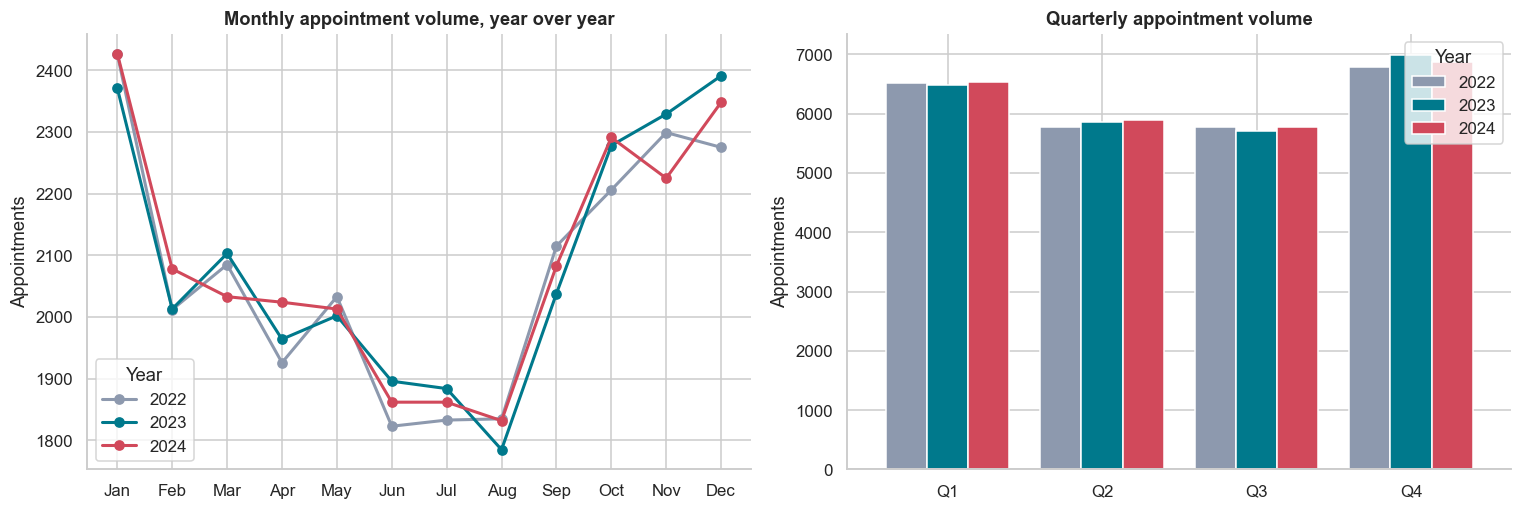

appointment_year,2022,2023,2024
appointments,"24,868.00","25,054.00","25,078.00"
YoY %,NaN,0.75,0.10


appointment_year,2022,2023,2024,Q share of year (avg %)
appointment_quarter,,,,
Q1,6523,6487,6538,26.06
Q2,5782,5862,5899,23.39
Q3,5783,5707,5777,23.02
Q4,6780,6998,6864,27.52


Linear trend across the 36 months: +1.7 appointments per month (mean 2,083/month) -> essentially flat
Seasonality: peak month = Jan, trough month = Aug; peak/trough ratio = 1.33x


In [6]:
# Business_overview
# 1. How is appointment volume trending across months and quarters, 2022 to 2024?

monthly = fact.groupby(['appointment_year', 'appointment_month']).size().unstack(0)
quarterly = fact.groupby(['appointment_year', 'appointment_quarter']).size().unstack(0)
yearly = fact.groupby('appointment_year').size()

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
for yr, c in zip(monthly.columns, [GREY, TEAL, RED]):
    ax[0].plot(MONTHS, monthly[yr], marker='o', lw=2, label=str(yr), color=c)
ax[0].set_title('Monthly appointment volume, year over year'); ax[0].set_ylabel('Appointments'); ax[0].legend(title='Year')
quarterly.plot(kind='bar', ax=ax[1], color=[GREY, TEAL, RED], width=0.8)
ax[1].set_title('Quarterly appointment volume'); ax[1].set_xlabel(''); ax[1].set_ylabel('Appointments')
ax[1].tick_params(axis='x', rotation=0); ax[1].legend(title='Year')
plt.tight_layout(); plt.show()

display(pd.concat([yearly.rename('appointments'), (yearly.pct_change() * 100).rename('YoY %')], axis=1).T)
q = quarterly.copy(); q['Q share of year (avg %)'] = (quarterly / quarterly.sum() * 100).mean(axis=1)
display(q)

ts = fact.set_index('appointment_date').resample('MS').size()
slope = np.polyfit(np.arange(len(ts)), ts.values, 1)[0]
print(f'Linear trend across the 36 months: {slope:+.1f} appointments per month (mean {ts.mean():,.0f}/month) -> essentially flat')
print(f'Seasonality: peak month = {MONTHS[monthly.mean(axis=1).idxmax()-1]}, trough month = {MONTHS[monthly.mean(axis=1).idxmin()-1]}; '
      f'peak/trough ratio = {monthly.mean(axis=1).max()/monthly.mean(axis=1).min():.2f}x')

,appointments,share_%
appointment_status,,
Completed,55275,73.70
No-Show,11584,15.45
Cancelled,5793,7.72
Scheduled,2348,3.13


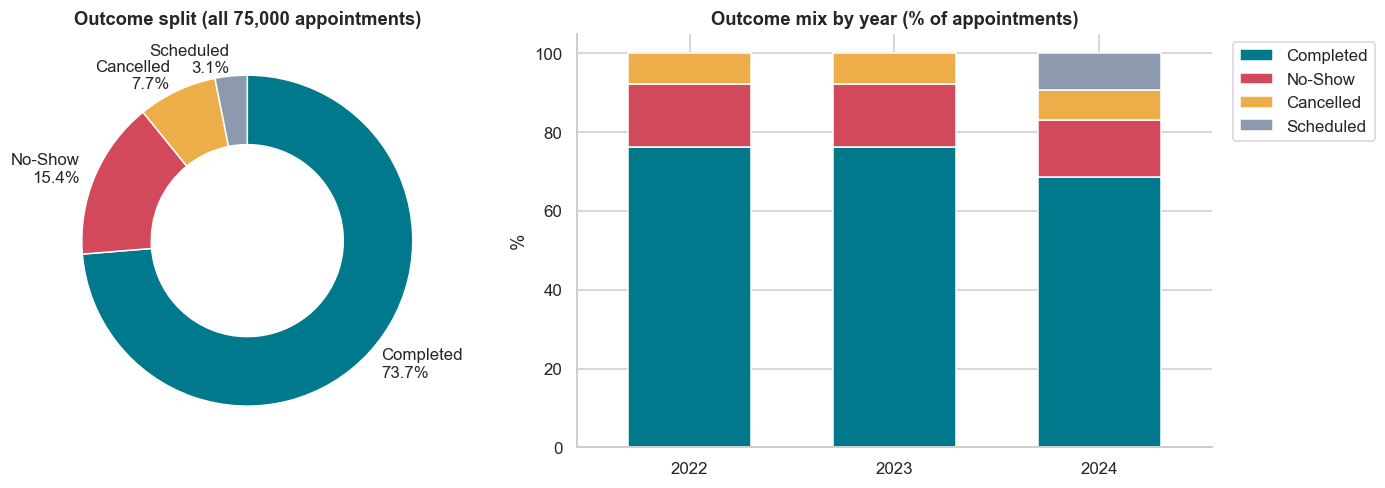

Of the 72,652 appointments with a known outcome: 76.1% completed, 15.9% no-show, 8.0% cancelled
Revenue lost proxy: 11,584 no-show slots x avg listed fee INR 1,703 = INR 19.7 M of listed consultation fees on the table


In [7]:
# 2.What is the split of outcomes: Completed, No-Show, Cancelled, Scheduled?
order = ['Completed', 'No-Show', 'Cancelled', 'Scheduled']
outcome = fact.appointment_status.value_counts().reindex(order)
outcome_df = pd.DataFrame({'appointments': outcome, 'share_%': outcome / outcome.sum() * 100})
display(outcome_df)

by_year = pd.crosstab(fact.appointment_year, fact.appointment_status, normalize='index').reindex(columns=order) * 100
palette = {'Completed': TEAL, 'No-Show': RED, 'Cancelled': '#edae49', 'Scheduled': GREY}

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={'width_ratios': [1, 1.2]})
ax[0].pie(outcome, labels=[f'{k}\n{v:.1f}%' for k, v in outcome_df['share_%'].items()], colors=[palette[k] for k in order],
          startangle=90, counterclock=False, wedgeprops=dict(width=0.42, edgecolor='white'))
ax[0].set_title('Outcome split (all 75,000 appointments)')
by_year.plot(kind='bar', stacked=True, ax=ax[1], color=[palette[k] for k in order], width=0.6)
ax[1].set_title('Outcome mix by year (% of appointments)'); ax[1].set_ylabel('%'); ax[1].set_xlabel('')
ax[1].tick_params(axis='x', rotation=0); ax[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

booked_resolved = outcome[['Completed', 'No-Show', 'Cancelled']]
print(f"Of the {booked_resolved.sum():,} appointments with a known outcome: "
      f"{booked_resolved['Completed']/booked_resolved.sum()*100:.1f}% completed, "
      f"{booked_resolved['No-Show']/booked_resolved.sum()*100:.1f}% no-show, "
      f"{booked_resolved['Cancelled']/booked_resolved.sum()*100:.1f}% cancelled")
print(f"Revenue lost proxy: {int(outcome['No-Show']):,} no-show slots x avg listed fee "
      f"INR {fact.loc[fact.appointment_status=='No-Show','consultation_fee'].mean():,.0f} = "
      f"INR {fact.loc[fact.appointment_status=='No-Show','consultation_fee'].sum()/1e6:,.1f} M of listed consultation fees on the table")


,appointments,share_%,cumulative_%
booking_channel,,,
Apollo App,34042,45.39,45.39
Website,18545,24.73,70.12
Call Centre,11201,14.93,85.05
Walk-In,7501,10.00,95.05
Partner App,3711,4.95,100.00


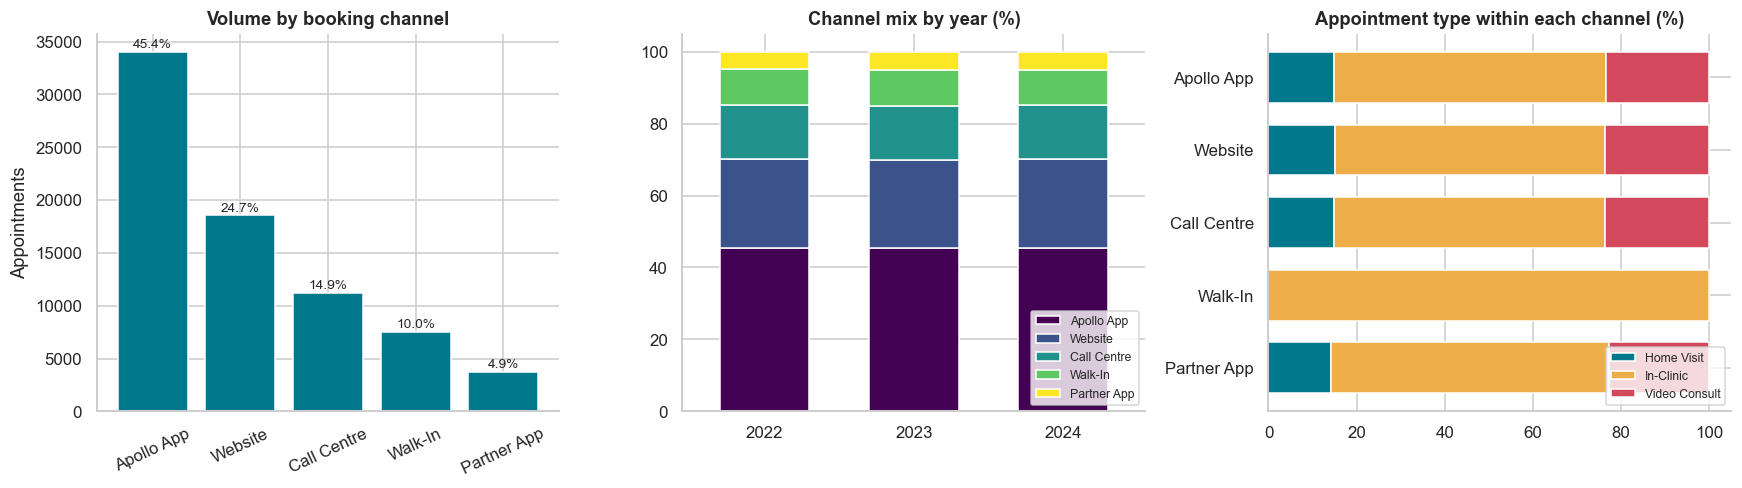

booking_channel,Apollo App,Website,Call Centre,Walk-In,Partner App
appointment_year,,,,,
2022,45.40,24.90,14.90,10.20,4.70
2023,45.30,24.60,15.00,9.90,5.20
2024,45.50,24.70,14.90,9.90,5.00


In [8]:
# 3. Which booking channels drive the most volume, and what does the channel mix look like?
ch = fact.booking_channel.value_counts()
ch_df = pd.DataFrame({'appointments': ch, 'share_%': ch / ch.sum() * 100}); ch_df['cumulative_%'] = ch_df['share_%'].cumsum()
display(ch_df)

mix_year = pd.crosstab(fact.appointment_year, fact.booking_channel, normalize='index')[ch.index] * 100
mix_type = pd.crosstab(fact.booking_channel, fact.appointment_type, normalize='index').loc[ch.index] * 100

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
ax[0].bar(ch.index, ch.values, color=TEAL)
for x, (v, s) in enumerate(zip(ch.values, ch_df['share_%'])): ax[0].text(x, v + 400, f'{s:.1f}%', ha='center', fontsize=9)
ax[0].set_title('Volume by booking channel'); ax[0].tick_params(axis='x', rotation=25); ax[0].set_ylabel('Appointments')
mix_year.plot(kind='bar', stacked=True, ax=ax[1], colormap='viridis', width=0.6)
ax[1].set_title('Channel mix by year (%)'); ax[1].tick_params(axis='x', rotation=0); ax[1].set_xlabel(''); ax[1].legend(fontsize=8, loc='lower right')
mix_type.plot(kind='barh', stacked=True, ax=ax[2], color=[TEAL, '#edae49', RED], width=0.7)
ax[2].set_title('Appointment type within each channel (%)'); ax[2].set_ylabel(''); ax[2].invert_yaxis(); ax[2].legend(fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()
display(mix_year.round(1))




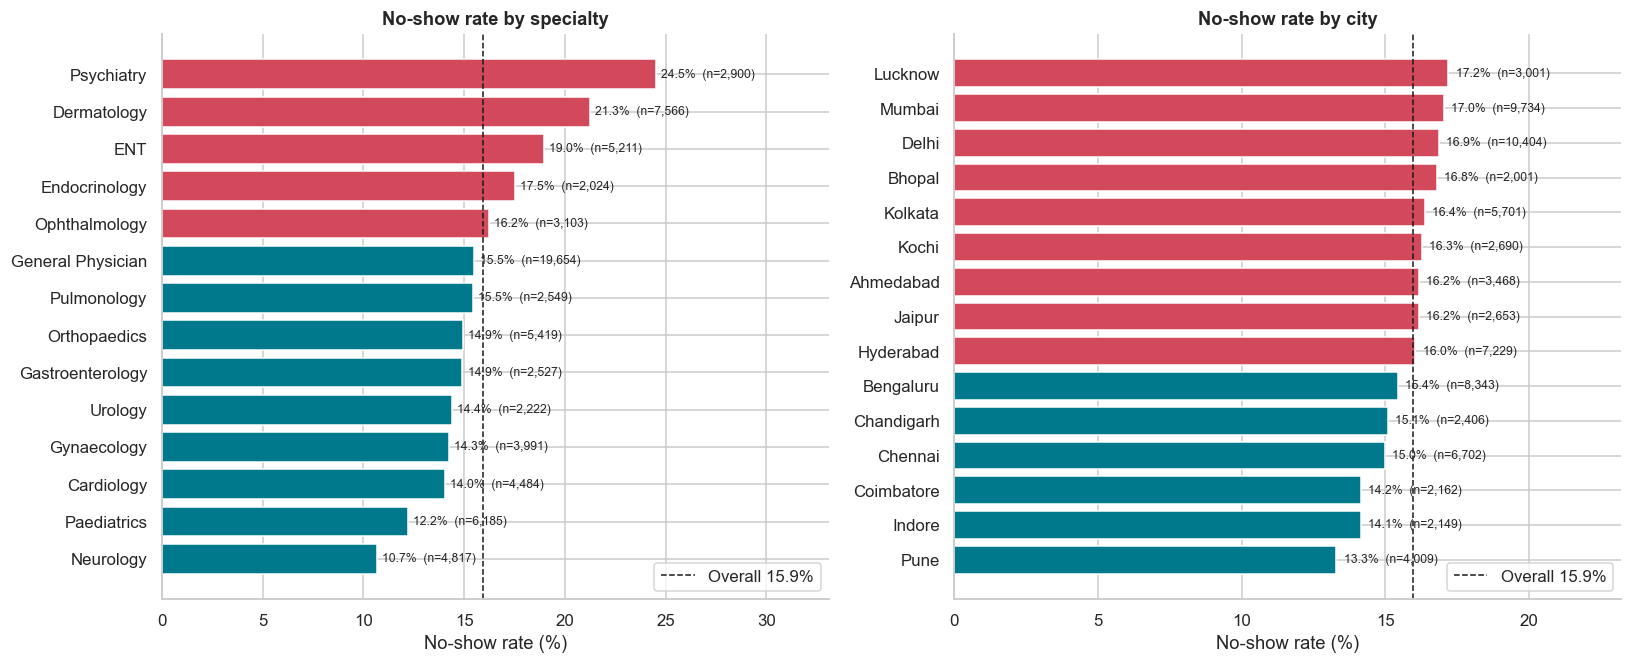

Specialty: highest = Psychiatry (24.5%), lowest = Neurology (10.7%), spread = 13.8 pp, ratio = 2.29x
City: highest = Lucknow (17.2%), lowest = Pune (13.3%), spread = 3.9 pp, ratio = 1.29x

specialty: chi-square = 554.5, p = 3.85e-110, Cramer's V = 0.087
city: chi-square = 60.0, p = 1.19e-07, Cramer's V = 0.029


,appointments,no_shows,no_show_rate,vs_overall_pp
specialty,,,,
Psychiatry,2900,711,24.52,8.57
Dermatology,7566,1608,21.25,5.31
ENT,5211,988,18.96,3.02
Cardiology,4484,629,14.03,-1.92
Paediatrics,6185,756,12.22,-3.72
Neurology,4817,515,10.69,-5.25


In [9]:
# No-show analysis
# 4. Which specialties and cities have the highest and lowest no-show rates?
spec = rate_table(resolved, 'specialty').sort_values('no_show_rate', ascending=False)
city = rate_table(resolved, 'city').sort_values('no_show_rate', ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(15, 6.2))
rate_barh(ax[0], spec, 'No-show rate by specialty')
rate_barh(ax[1], city, 'No-show rate by city')
plt.tight_layout(); plt.show()

for name, t in [('Specialty', spec), ('City', city)]:
    print(f'{name}: highest = {t.index[0]} ({t.no_show_rate.iloc[0]:.1f}%), lowest = {t.index[-1]} ({t.no_show_rate.iloc[-1]:.1f}%), '
          f'spread = {t.no_show_rate.iloc[0]-t.no_show_rate.iloc[-1]:.1f} pp, ratio = {t.no_show_rate.iloc[0]/t.no_show_rate.iloc[-1]:.2f}x')
print(); print(test_line(resolved, 'specialty')); print(test_line(resolved, 'city'))
display(pd.concat([spec.head(3), spec.tail(3)]))




,appointments,no_shows,no_show_rate,vs_overall_pp,rate_excl_walkins
lead_bucket,,,,,
Same day,20180,3193,15.82,-0.12,12.97
1 day,10453,1382,13.22,-2.72,13.22
2-3 days,15022,2269,15.10,-0.84,15.10
4-7 days,15897,2623,16.50,0.56,16.50
8-14 days,8758,1648,18.82,2.87,18.82
15-21 days,1851,361,19.50,3.56,19.50
22-30 days,491,108,22.00,6.05,22.00


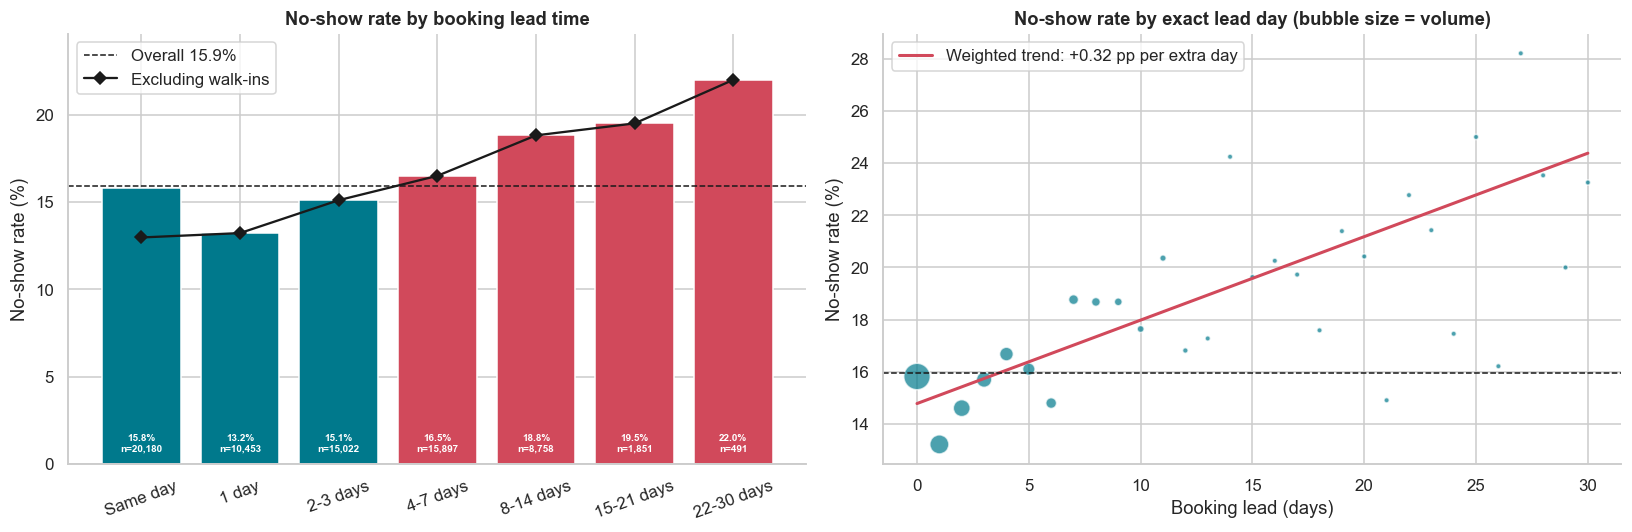

Point-biserial correlation (lead days vs no-show): r = 0.038, p = 4.93e-25
Lead bucket: chi-square = 154.5, p = 8.78e-31, Cramer's V = 0.046
Booked 0-3 days ahead: 15.0%   |   booked 15+ days ahead: 20.0%   -> 1.34x


In [10]:
# 5. How does booking lead time affect the probability of a no-show?
LEAD_BINS = [-1, 0, 1, 3, 7, 14, 21, 30]
LEAD_LABELS = ['Same day', '1 day', '2-3 days', '4-7 days', '8-14 days', '15-21 days', '22-30 days']
resolved['lead_bucket'] = pd.cut(resolved.booking_lead_days, LEAD_BINS, labels=LEAD_LABELS)

lead = rate_table(resolved, 'lead_bucket')
lead_nw = rate_table(resolved[resolved.booking_channel != 'Walk-In'], 'lead_bucket')
display(lead.join(lead_nw.no_show_rate.rename('rate_excl_walkins')))

daily = resolved.groupby('booking_lead_days').no_show_flag.agg(['mean', 'size'])
daily['mean'] *= 100

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
rate_bar(ax[0], lead, 'No-show rate by booking lead time', rot=20)
ax[0].plot(lead_nw.index.astype(str), lead_nw.no_show_rate, color='k', marker='D', lw=1.5, label='Excluding walk-ins'); ax[0].legend(loc='upper left')
sizes = np.clip(daily['size'] / daily['size'].max() * 300, 12, 300)
ax[1].scatter(daily.index, daily['mean'], s=sizes, color=TEAL, alpha=.7, edgecolor='white')
z = np.polyfit(daily.index, daily['mean'], 1, w=np.sqrt(daily['size']))
ax[1].plot(daily.index, np.polyval(z, daily.index), color=RED, lw=2, label=f'Weighted trend: {z[0]:+.2f} pp per extra day')
ax[1].axhline(OVERALL, color='k', ls='--', lw=1); ax[1].set_xlabel('Booking lead (days)'); ax[1].set_ylabel('No-show rate (%)')
ax[1].set_title('No-show rate by exact lead day (bubble size = volume)'); ax[1].legend()
plt.tight_layout(); plt.show()

r, p = stats.pointbiserialr(resolved.booking_lead_days, resolved.no_show_flag)
print(f'Point-biserial correlation (lead days vs no-show): r = {r:.3f}, p = {p:.2e}')
print(test_line(resolved, 'lead_bucket', 'Lead bucket'))
short, long_ = resolved[resolved.booking_lead_days <= 3], resolved[resolved.booking_lead_days >= 15]
print(f'Booked 0-3 days ahead: {short.no_show_flag.mean()*100:.1f}%   |   booked 15+ days ahead: {long_.no_show_flag.mean()*100:.1f}%   '
      f'-> {long_.no_show_flag.mean()/short.no_show_flag.mean():.2f}x')



How time_of_day is bucketed (hours):


time_of_day,Morning,Afternoon,Evening
min,8,12,17
max,11,16,19


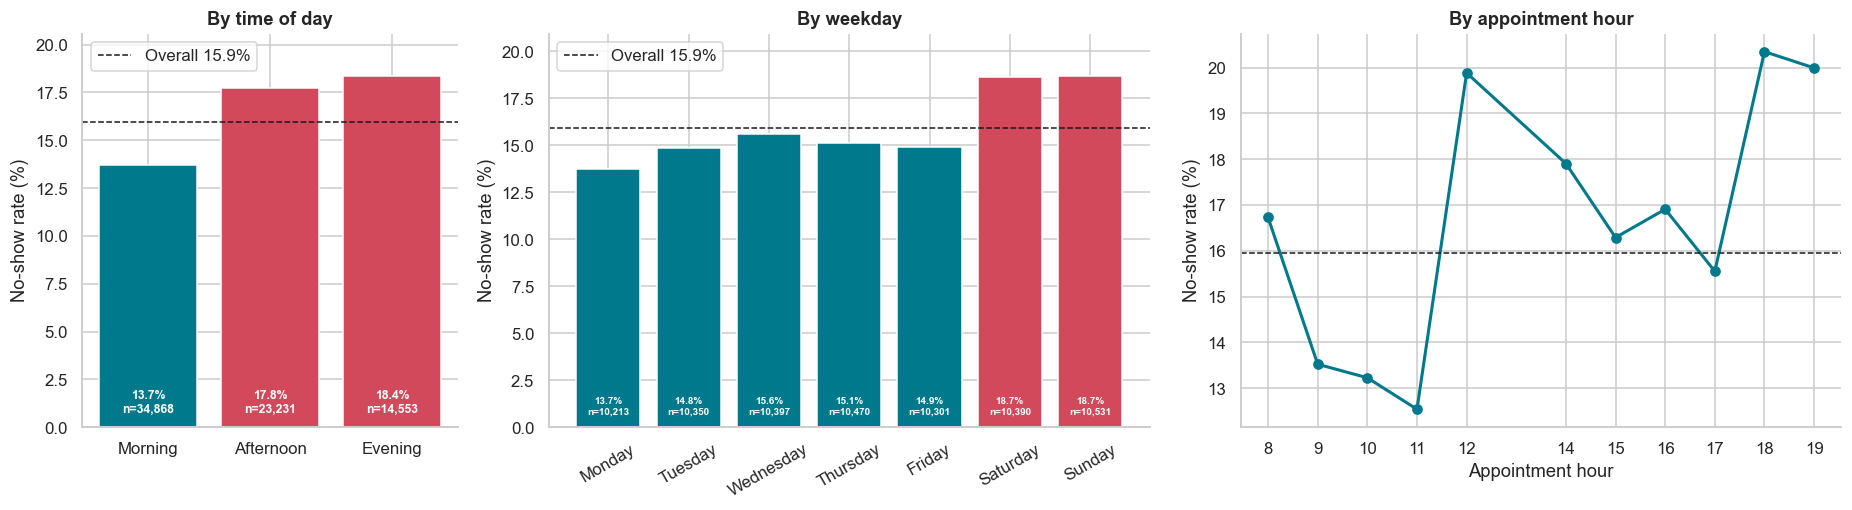

,appointments,no_shows,no_show_rate,vs_overall_pp
day_type,,,,
Weekday,51731,7676,14.84,-1.11
Weekend,20921,3908,18.68,2.74


In [11]:
# 6. Do evening slots, weekends and longer-lead bookings see higher dropout?
print('How time_of_day is bucketed (hours):')
display(fact.groupby('time_of_day').appointment_hour.agg(['min', 'max']).loc[['Morning', 'Afternoon', 'Evening']].T)

resolved['is_weekend'] = resolved.appointment_day.isin(['Saturday', 'Sunday'])
resolved['day_type'] = np.where(resolved.is_weekend, 'Weekend', 'Weekday')
tod = rate_table(resolved, 'time_of_day').loc[['Morning', 'Afternoon', 'Evening']]
dow = rate_table(resolved, 'appointment_day').loc[WEEK]
hour = rate_table(resolved, 'appointment_hour')
dtype_ = rate_table(resolved, 'day_type')

fig, ax = plt.subplots(1, 3, figsize=(17, 4.8), gridspec_kw={'width_ratios': [1, 1.6, 1.6]})
rate_bar(ax[0], tod, 'By time of day')
rate_bar(ax[1], dow, 'By weekday', rot=30)
ax[2].plot(hour.index, hour.no_show_rate, marker='o', color=TEAL, lw=2)
ax[2].axhline(OVERALL, color='k', ls='--', lw=1); ax[2].set_xticks(hour.index); ax[2].set_xlabel('Appointment hour'); ax[2].set_ylabel('No-show rate (%)')
ax[2].set_title('By appointment hour')
plt.tight_layout(); plt.show()
display(dtype_)

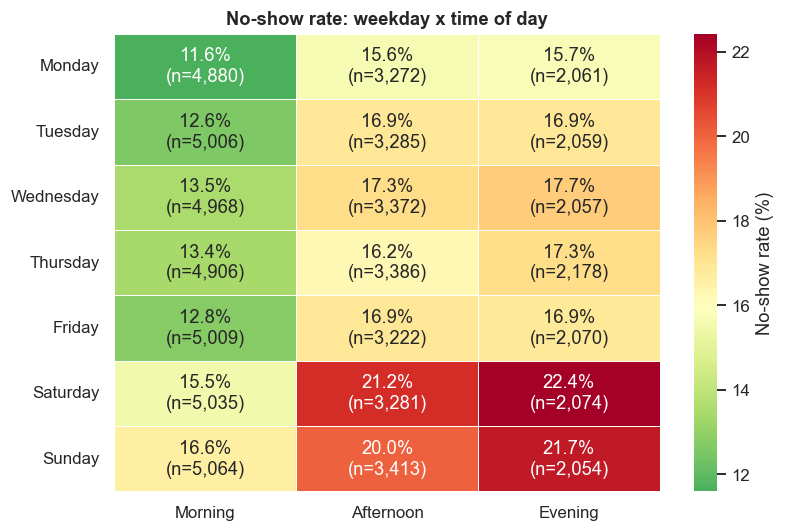

,rate_long_%,rate_short_%,relative_risk,n_long
Long-lead threshold (days),,,,
>= 7,19.01,15.22,1.25,13908
>= 10,19.29,15.58,1.24,7096
>= 14,20.88,15.74,1.33,2936
>= 21,20.66,15.90,1.30,605


In [13]:
# Heatmap: weekday x time of day (rate and volume)
piv = resolved.pivot_table(index='appointment_day', columns='time_of_day', values='no_show_flag', aggfunc='mean').loc[WEEK, ['Morning', 'Afternoon', 'Evening']] * 100
cnt = resolved.pivot_table(index='appointment_day', columns='time_of_day', values='no_show_flag', aggfunc='size').loc[WEEK, ['Morning', 'Afternoon', 'Evening']]
annot = piv.round(1).astype(str) + '%\n(n=' + cnt.applymap('{:,}'.format) + ')'
plt.figure(figsize=(7.5, 5))
sns.heatmap(piv, annot=annot, fmt='', cmap='RdYlGn_r', center=OVERALL, cbar_kws={'label': 'No-show rate (%)'}, linewidths=.5)
plt.title('No-show rate: weekday x time of day'); plt.ylabel(''); plt.xlabel('')
plt.tight_layout(); plt.show()

# Long-lead: does the threshold matter? 
LONG_LEAD = 14
rows = []
for th in [7, 10, 14, 21]:
    a, b = resolved[resolved.booking_lead_days >= th], resolved[resolved.booking_lead_days < th]
    rows.append({'Long-lead threshold (days)': f'>= {th}', 'rate_long_%': a.no_show_flag.mean()*100, 'rate_short_%': b.no_show_flag.mean()*100,
                 'relative_risk': a.no_show_flag.mean()/b.no_show_flag.mean(), 'n_long': len(a)})
display(pd.DataFrame(rows).set_index('Long-lead threshold (days)'))

,profile,risk_flags,appointments,no_show_rate
0,Evening + Weekend + Long-lead,3,164,23.17
1,Evening + Long-lead,2,413,22.52
2,Weekend + Long-lead,2,677,22.16
3,Evening + Weekend,2,3964,22.00
4,Long-lead,1,1682,19.74
5,Weekend,1,16116,17.67
6,Evening,1,10012,16.68
7,None (baseline),0,39624,14.08


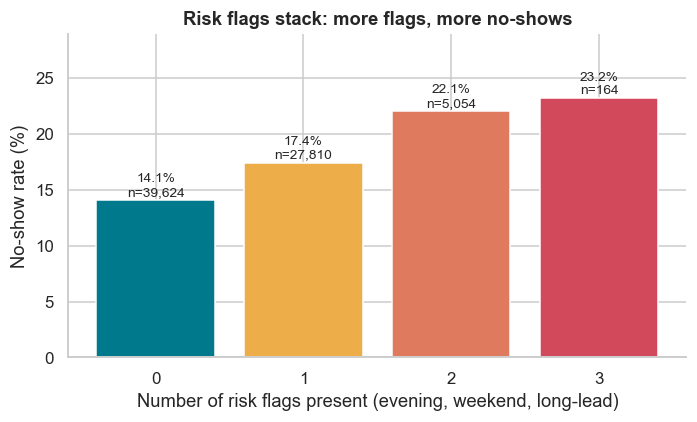

In [16]:
# Do the risks stack? Evening x weekend x long-lead (>=14d) 
resolved['evening'] = resolved.time_of_day.eq('Evening')
resolved['long_lead'] = resolved.booking_lead_days >= LONG_LEAD
stack = (resolved.groupby(['evening', 'is_weekend', 'long_lead']).no_show_flag.agg(appointments='size', no_show_rate='mean')
         .reset_index())
stack['no_show_rate'] *= 100
stack['risk_flags'] = stack[['evening', 'is_weekend', 'long_lead']].sum(axis=1)
stack['profile'] = stack.apply(lambda r: ' + '.join([n for n, f in [('Evening', r.evening), ('Weekend', r.is_weekend), ('Long-lead', r.long_lead)] if f]) or 'None (baseline)', axis=1)
stack = stack.sort_values('no_show_rate', ascending=False)
display(stack[['profile', 'risk_flags', 'appointments', 'no_show_rate']].reset_index(drop=True))

by_flags = resolved.assign(flags=resolved[['evening', 'is_weekend', 'long_lead']].sum(axis=1)).groupby('flags').no_show_flag.agg(['size', 'mean'])
by_flags['mean'] *= 100
plt.figure(figsize=(6.5, 4))
plt.bar(by_flags.index.astype(str), by_flags['mean'], color=[TEAL, '#edae49', '#e07a5f', RED])
for i, (n, m) in enumerate(zip(by_flags['size'], by_flags['mean'])): plt.text(i, m + .4, f'{m:.1f}%\nn={n:,}', ha='center', fontsize=9)
plt.xlabel('Number of risk flags present (evening, weekend, long-lead)'); plt.ylabel('No-show rate (%)'); plt.ylim(0, by_flags['mean'].max() * 1.25)
plt.title('Risk flags stack: more flags, more no-shows'); plt.tight_layout(); plt.show()

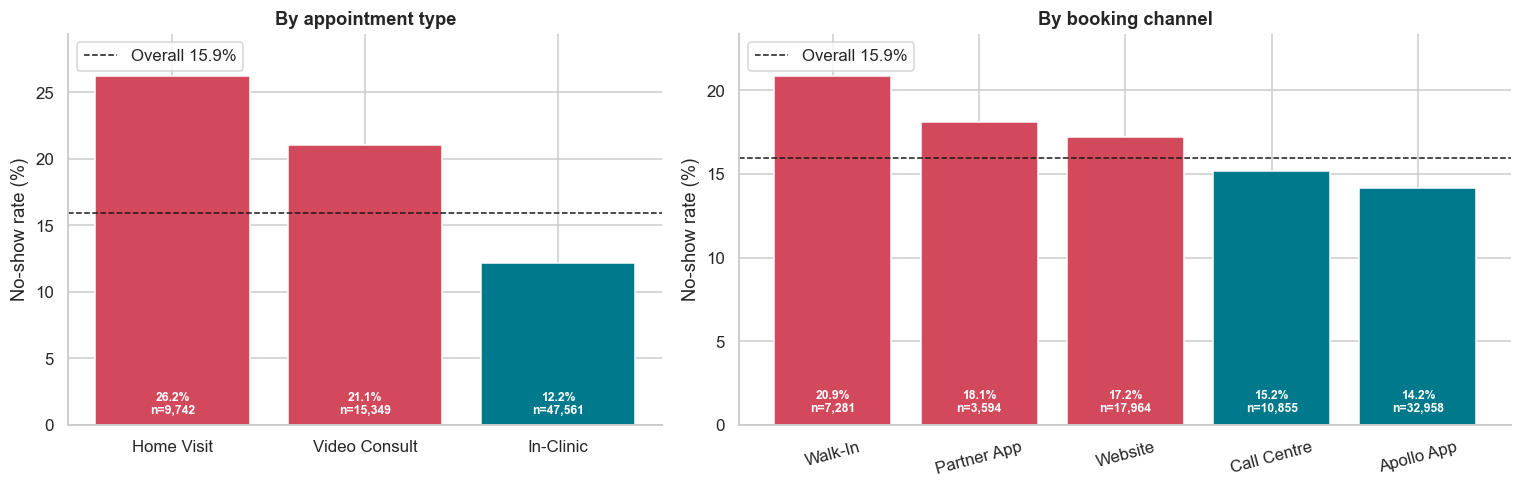

appointment_type: chi-square = 1,572.6, p = 0.00e+00, Cramer's V = 0.147
booking_channel: chi-square = 247.1, p = 2.77e-52, Cramer's V = 0.058


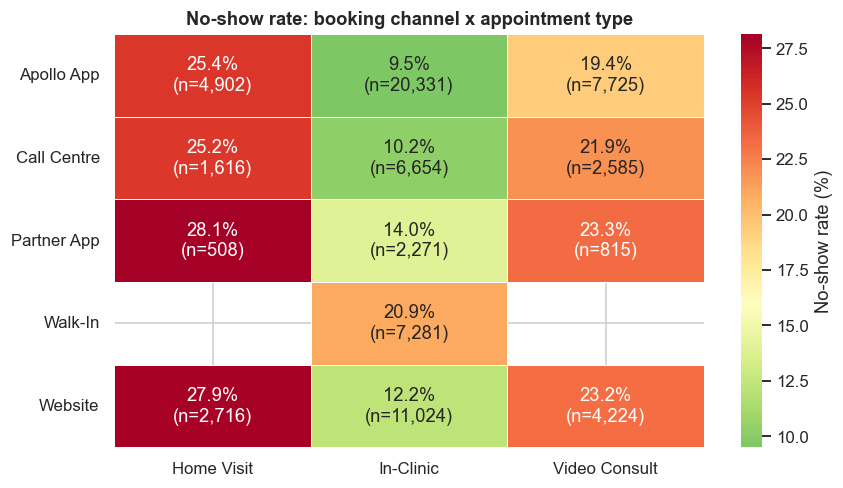

In [18]:
# 7. Which appointment types and booking channels carry the most no-show risk?
atype = rate_table(resolved, 'appointment_type').sort_values('no_show_rate', ascending=False)
chan = rate_table(resolved, 'booking_channel').sort_values('no_show_rate', ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={'width_ratios': [1, 1.3]})
rate_bar(ax[0], atype, 'By appointment type')
rate_bar(ax[1], chan, 'By booking channel', rot=15)
plt.tight_layout(); plt.show()
print(test_line(resolved, 'appointment_type')); print(test_line(resolved, 'booking_channel'))

# ----- Channel x type interaction -----
piv = resolved.pivot_table(index='booking_channel', columns='appointment_type', values='no_show_flag', aggfunc='mean') * 100
cnt = resolved.pivot_table(index='booking_channel', columns='appointment_type', values='no_show_flag', aggfunc='size')
annot = piv.round(1).astype(str).where(piv.notna(), '') + '%\n(n=' + cnt.applymap(lambda v: f'{v:,.0f}' if pd.notna(v) else '') + ')'
annot = annot.where(piv.notna(), '')
plt.figure(figsize=(8, 4.6))
sns.heatmap(piv, annot=annot, fmt='', cmap='RdYlGn_r', center=OVERALL, linewidths=.5, cbar_kws={'label': 'No-show rate (%)'})
plt.title('No-show rate: booking channel x appointment type'); plt.xlabel(''); plt.ylabel('')
plt.tight_layout(); plt.show()

,appointments,no_shows,no_show_rate,vs_overall_pp
reminder_type,,,,
No Reminder,10977,3311,30.16,14.22
SMS Only,14527,2363,16.27,0.32
SMS + WhatsApp,25273,3414,13.51,-2.44
SMS + WhatsApp + Call,21875,2496,11.41,-4.53


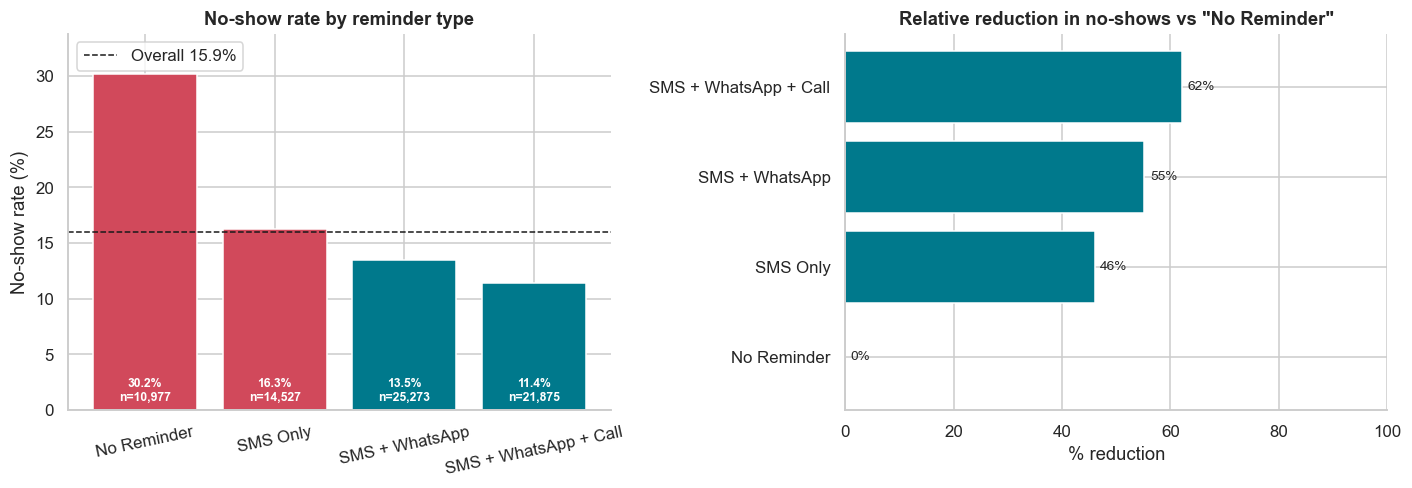

Reminder type: chi-square = 2,104.4, p = 0.00e+00, Cramer's V = 0.170
SMS Only: 16.3% vs No Reminder 30.2% -> 46% relative reduction, 1.9x lower odds of no-show
SMS + WhatsApp: 13.5% vs No Reminder 30.2% -> 55% relative reduction, 2.2x lower odds of no-show
SMS + WhatsApp + Call: 11.4% vs No Reminder 30.2% -> 62% relative reduction, 2.6x lower odds of no-show


In [19]:
# Reminder and Engagement Effectiveness 
# 1. How much does reminder type reduce no-show rates vs no reminder?
remtype = rate_table(resolved, 'reminder_type').reindex(['No Reminder', 'SMS Only', 'SMS + WhatsApp', 'SMS + WhatsApp + Call']).dropna(how='all')
remtype['appointments'] = remtype['appointments'].astype(int); remtype['no_shows'] = remtype['no_shows'].astype(int)
display(remtype)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
rate_bar(ax[0], remtype, 'No-show rate by reminder type', rot=12)
none_rate = remtype.loc['No Reminder', 'no_show_rate']
red = (none_rate - remtype.no_show_rate) / none_rate * 100
ax[1].barh(remtype.index, red, color=TEAL)
for y, v in enumerate(red): ax[1].text(v + 1, y, f'{v:.0f}%', va='center', fontsize=9)
ax[1].set_title('Relative reduction in no-shows vs "No Reminder"'); ax[1].set_xlabel('% reduction'); ax[1].set_xlim(0, 100)
plt.tight_layout(); plt.show()
print(test_line(resolved, 'reminder_type', 'Reminder type'))
for rt in ['SMS Only', 'SMS + WhatsApp', 'SMS + WhatsApp + Call']:
    print(f'{rt}: {remtype.loc[rt,"no_show_rate"]:.1f}% vs No Reminder {none_rate:.1f}% -> {red[rt]:.0f}% relative reduction, '
          f'{none_rate/remtype.loc[rt,"no_show_rate"]:.1f}x lower odds of no-show')


,appointments,no_shows,no_show_rate,vs_overall_pp
patient_prior_no_shows,,,,
0,63014,9549,15.15,-0.79
1,8502,1723,20.27,4.32
2,983,262,26.65,10.71
3,134,41,30.60,14.65


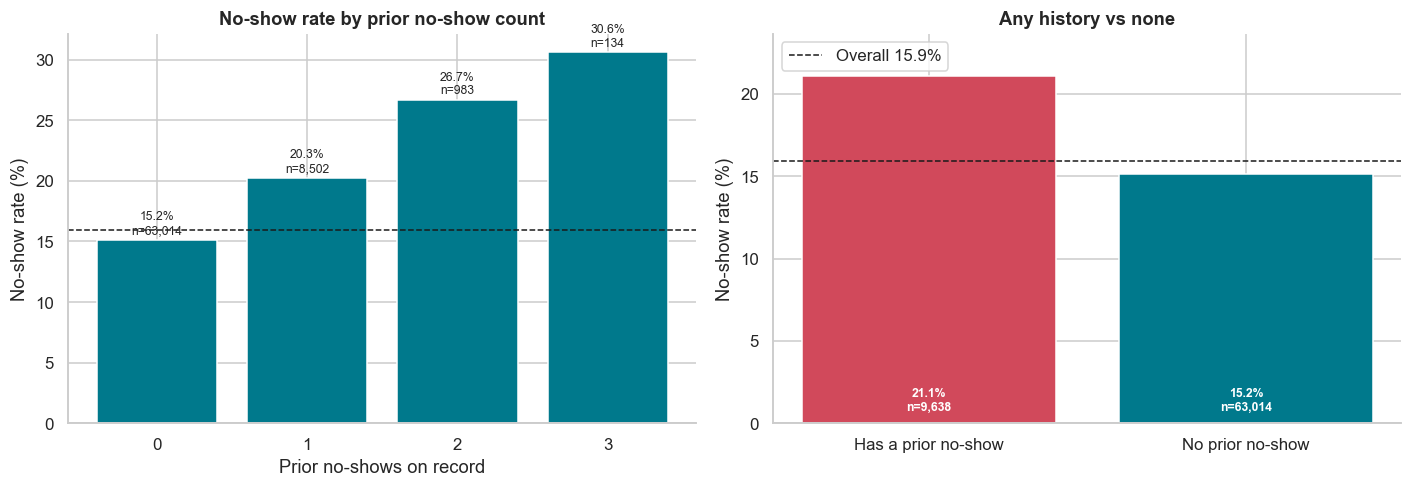

Correlation (prior no-shows, capped at 3, vs no-show): r = 0.060, p = 3.19e-59
0 priors: 15.2%  |  1 prior: 20.3%  |  2 priors: 26.7%  -> risk compounds with each additional prior no-show


In [20]:
# 2. Does prior no-show history predict future no-show behaviour?
prior = rate_table(resolved, 'patient_prior_no_shows')
prior = prior[prior.appointments >= 20]  # drop the handful of patients with 4+ priors (very small n)
display(prior)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
ax[0].bar(prior.index.astype(str), prior.no_show_rate, color=TEAL)
for x, (r, n) in enumerate(zip(prior.no_show_rate, prior.appointments)): ax[0].text(x, r + .5, f'{r:.1f}%\nn={n:,}', ha='center', fontsize=8)
ax[0].axhline(OVERALL, color='k', ls='--', lw=1); ax[0].set_xlabel('Prior no-shows on record'); ax[0].set_ylabel('No-show rate (%)')
ax[0].set_title('No-show rate by prior no-show count')

ever = rate_table(resolved, resolved.patient_prior_no_shows.gt(0).map({True: 'Has a prior no-show', False: 'No prior no-show'}))
rate_bar(ax[1], ever, 'Any history vs none')
plt.tight_layout(); plt.show()

r_, p_ = stats.pointbiserialr(resolved.patient_prior_no_shows.clip(upper=3), resolved.no_show_flag)
print(f'Correlation (prior no-shows, capped at 3, vs no-show): r = {r_:.3f}, p = {p_:.2e}')
base, one = prior.loc[0, 'no_show_rate'], prior.loc[1, 'no_show_rate']
print(f'0 priors: {base:.1f}%  |  1 prior: {one:.1f}%  |  2 priors: {prior.loc[2,"no_show_rate"]:.1f}%  -> risk compounds with each additional prior no-show')



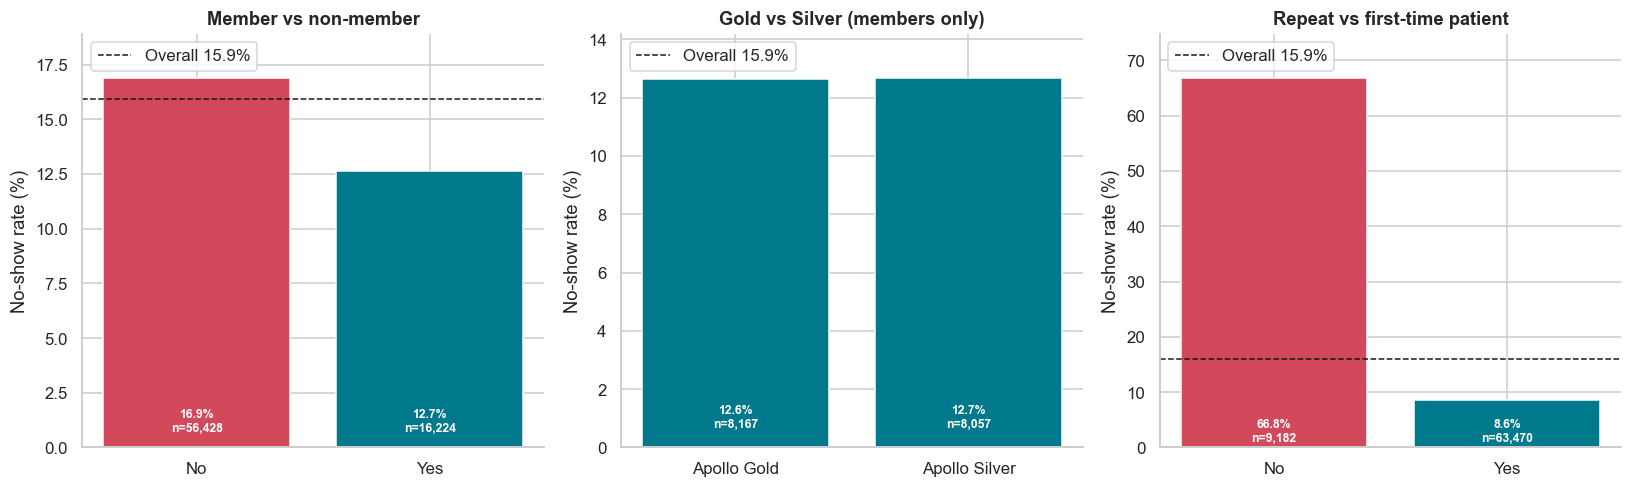

Membership: chi-square = 167.8, p = 2.24e-38, Cramer's V = 0.048
Repeat visit: chi-square = 20,264.2, p = 0.00e+00, Cramer's V = 0.528
Members: 12.7% vs non-members: 16.9% (4.2 pp gap)
Gold 12.6% vs Silver 12.7% -> tier itself barely matters, membership status does


In [21]:
# 3.Do Apollo members and repeat patients show better attendance than non-members and first-timers?
mem = rate_table(resolved, 'apollo_member')
mtype = rate_table(resolved[resolved.apollo_member == 'Yes'], 'membership_type')
rep = rate_table(resolved, 'repeat_visit')

fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
rate_bar(ax[0], mem, 'Member vs non-member')
rate_bar(ax[1], mtype, 'Gold vs Silver (members only)')
rate_bar(ax[2], rep, 'Repeat vs first-time patient')
plt.tight_layout(); plt.show()
for lbl, df_, col in [('Membership', resolved, 'apollo_member'), ('Repeat visit', resolved, 'repeat_visit')]:
    print(test_line(df_, col, lbl))
print(f"Members: {mem.loc['Yes','no_show_rate']:.1f}% vs non-members: {mem.loc['No','no_show_rate']:.1f}% "
      f"({mem.loc['No','no_show_rate']-mem.loc['Yes','no_show_rate']:.1f} pp gap)")
print(f"Gold {mtype.loc['Apollo Gold','no_show_rate']:.1f}% vs Silver {mtype.loc['Apollo Silver','no_show_rate']:.1f}% -> tier itself barely matters, membership status does")

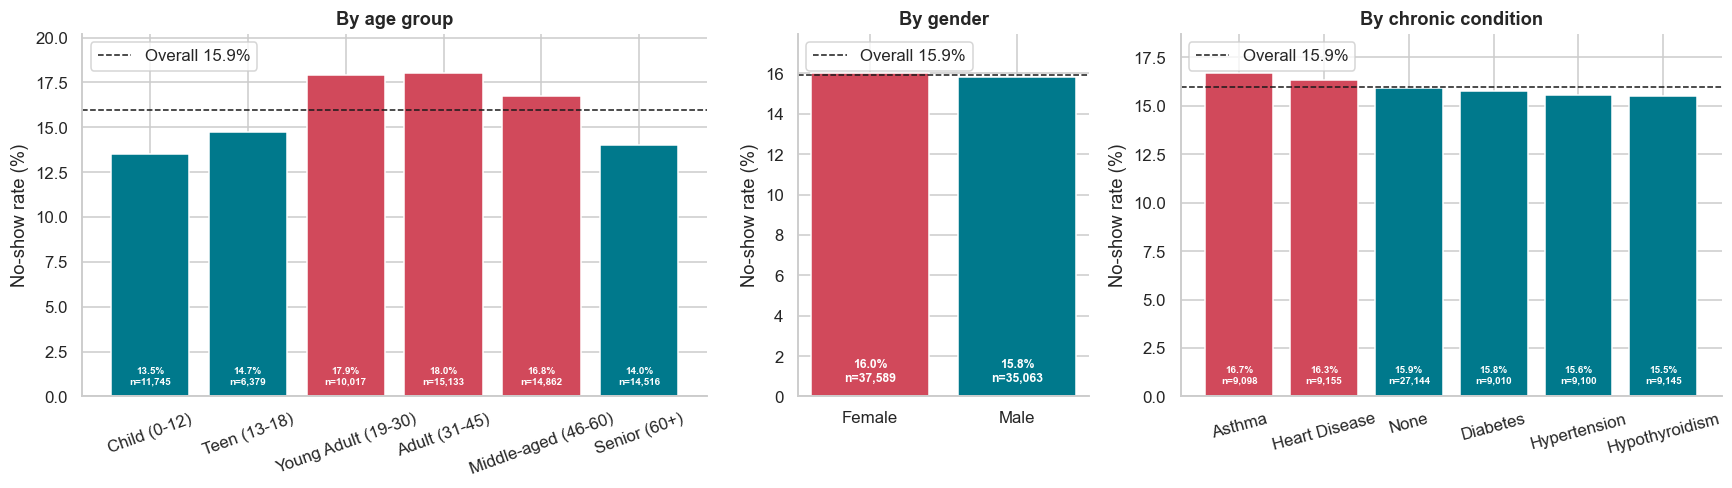

Age group: chi-square = 184.8, p = 5.04e-38, Cramer's V = 0.050
Gender: chi-square = 0.5, p = 4.76e-01, Cramer's V = 0.003
Chronic condition: chi-square = 7.4, p = 1.91e-01, Cramer's V = 0.010


In [22]:
# Patient & demographic segmentation
# 1.How do age group, gender, and chronic condition status influence no-show likelihood?
age_order = ['Child (0-12)', 'Teen (13-18)', 'Young Adult (19-30)', 'Adult (31-45)', 'Middle-aged (46-60)', 'Senior (60+)']
age = rate_table(resolved, 'age_group').reindex(age_order)
gender = rate_table(resolved, 'patient_gender')
chronic = rate_table(resolved, resolved.patient_chronic_condition.fillna('None')).sort_values('no_show_rate', ascending=False)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6), gridspec_kw={'width_ratios': [1.5, 0.7, 1.3]})
rate_bar(ax[0], age, 'By age group', rot=20)
rate_bar(ax[1], gender, 'By gender')
rate_bar(ax[2], chronic, 'By chronic condition', rot=15)
plt.tight_layout(); plt.show()
for lbl, col in [('Age group', 'age_group'), ('Gender', 'patient_gender')]:
    print(test_line(resolved, col, lbl))
print(test_line(resolved.assign(cc=resolved.patient_chronic_condition.fillna('None')), 'cc', 'Chronic condition'))

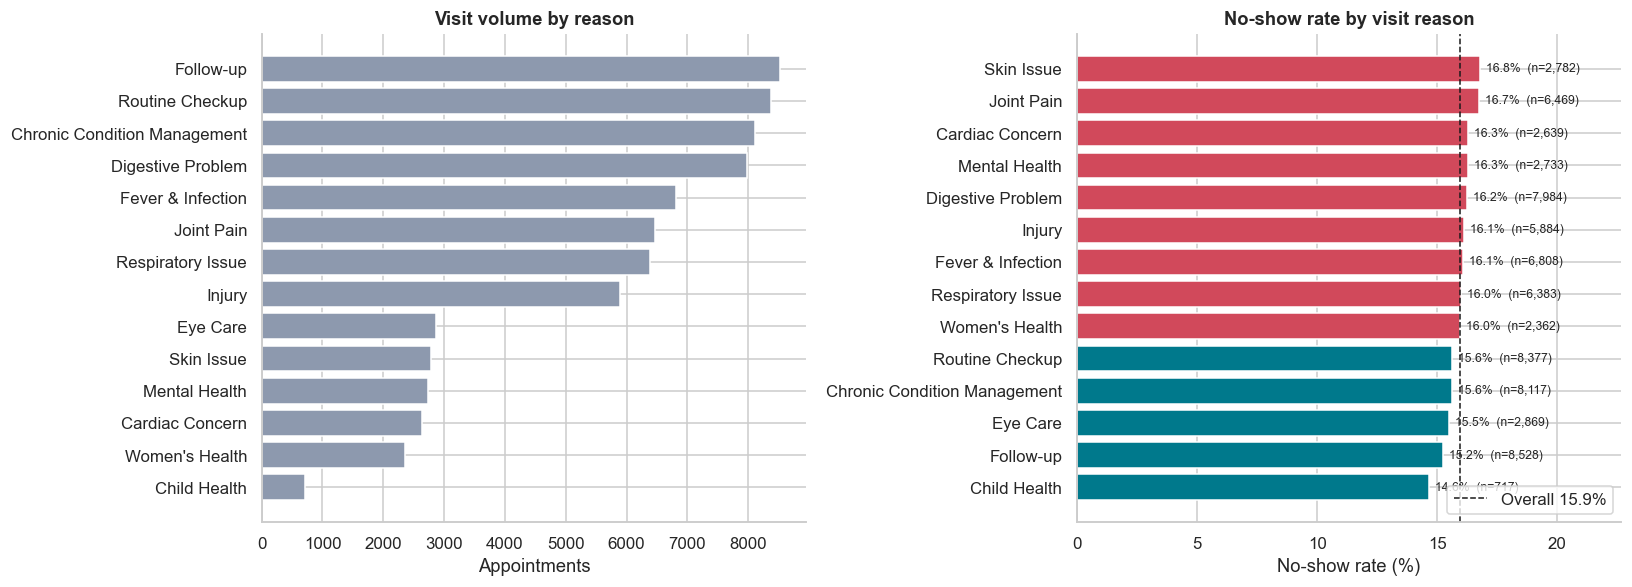

Visit reason: chi-square = 11.8, p = 5.47e-01, Cramer's V = 0.013


In [23]:
# 2. Which visit reasons are most common, and are some associated with higher dropout?
reason = rate_table(resolved, 'visit_reason').sort_values('appointments', ascending=False)
reason_by_rate = reason.sort_values('no_show_rate', ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
ax[0].barh(reason.index, reason.appointments, color=GREY)
ax[0].invert_yaxis(); ax[0].set_title('Visit volume by reason'); ax[0].set_xlabel('Appointments')
rate_barh(ax[1], reason_by_rate, 'No-show rate by visit reason')
plt.tight_layout(); plt.show()
print(test_line(resolved, 'visit_reason', 'Visit reason'))

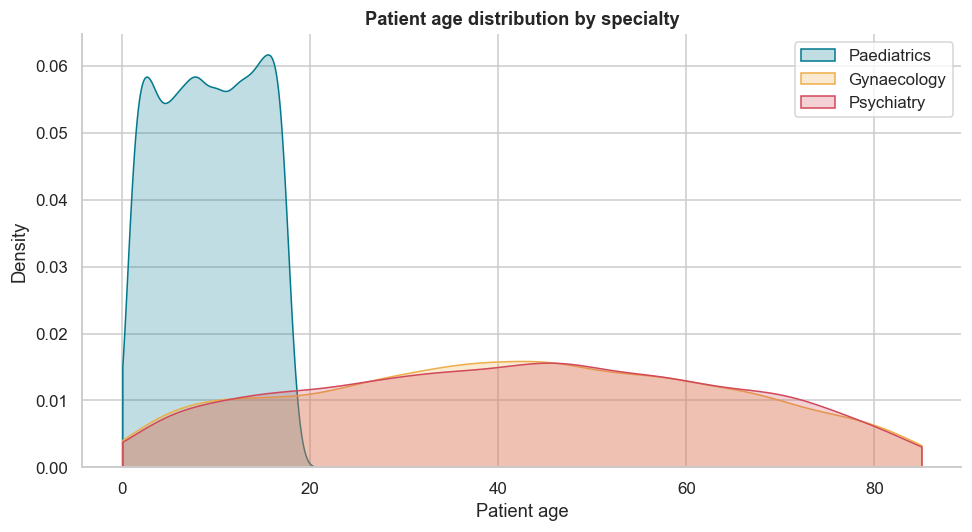

,mean,std,min,25%,50%,75%,max
specialty,,,,,,,
Paediatrics,9.30,5.00,1.00,5.00,9.00,14.00,18.00
Gynaecology,41.70,21.70,1.00,25.00,42.00,59.00,85.00
Psychiatry,42.00,21.70,1.00,25.00,42.00,59.00,85.00


In [24]:
# 3. Patient age distribution within Paediatrics, Gynaecology, and Psychiatry
focus = ['Paediatrics', 'Gynaecology', 'Psychiatry']
sub = fact[fact.specialty.isin(focus)]

plt.figure(figsize=(9, 5))
for spec, c in zip(focus, [TEAL, '#edae49', RED]):
    sns.kdeplot(sub.loc[sub.specialty == spec, 'patient_age'], fill=True, alpha=.25, label=spec, color=c, clip=(0, 85))
plt.title('Patient age distribution by specialty'); plt.xlabel('Patient age'); plt.ylabel('Density'); plt.legend()
plt.tight_layout(); plt.show()

display(sub.groupby('specialty').patient_age.describe()[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].loc[focus].round(1))

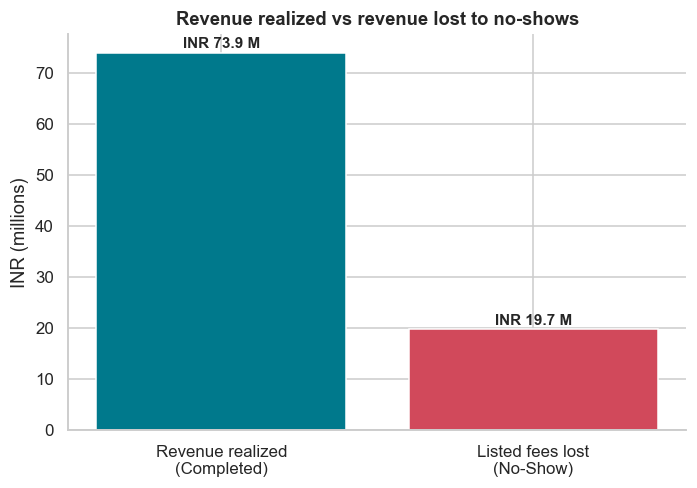

Revenue realized (Completed only): INR 73.9 M across 55,275 appointments
Listed fees forgone to 11,584 no-shows: INR 19.7 M (21.1% of realized+lost revenue; avg listed fee per no-show = INR 1,703)
Annualised: roughly INR 6.6 M/year in forgone listed fees at current no-show rates (3-year data)


In [25]:
# Financial performance
# 1. How much revenue is lost to no-shows?
completed = fact[fact.appointment_status == 'Completed'].copy()
noshow = fact[fact.appointment_status == 'No-Show']

realized = completed.revenue_realized.sum()
lost_listed = noshow.consultation_fee.sum()          # proxy: listed fee never collected
lost_share = lost_listed / (realized + lost_listed) * 100

fig, ax = plt.subplots(figsize=(6.5, 4.6))
ax.bar(['Revenue realized\n(Completed)', 'Listed fees lost\n(No-Show)'], [realized/1e6, lost_listed/1e6], color=[TEAL, RED])
for x, v in enumerate([realized/1e6, lost_listed/1e6]): ax.text(x, v + 1, f'INR {v:,.1f} M', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('INR (millions)'); ax.set_title('Revenue realized vs revenue lost to no-shows')
plt.tight_layout(); plt.show()

print(f'Revenue realized (Completed only): INR {realized/1e6:,.1f} M across {len(completed):,} appointments')
print(f'Listed fees forgone to {len(noshow):,} no-shows: INR {lost_listed/1e6:,.1f} M '
      f'({lost_share:.1f}% of realized+lost revenue; avg listed fee per no-show = INR {noshow.consultation_fee.mean():,.0f})')
print(f'Annualised: roughly INR {lost_listed/3/1e6:,.1f} M/year in forgone listed fees at current no-show rates (3-year data)')

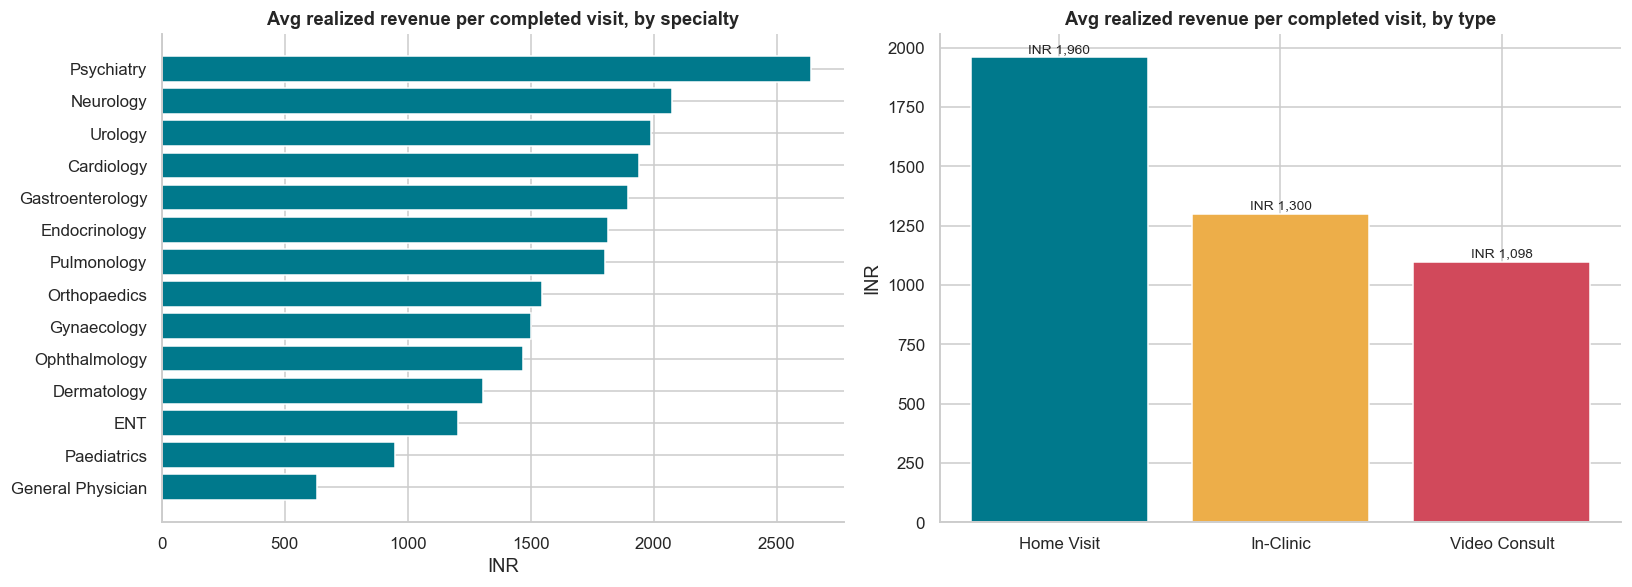

,avg_revenue,total_revenue,appointments
specialty,,,
Psychiatry,"2,640.00",5169997,1958
Neurology,"2,076.00",8096193,3899
Urology,"1,989.00",3438326,1729
Cardiology,"1,941.00",6806264,3507
Gastroenterology,"1,897.00",3740521,1972
Endocrinology,"1,813.00",2726278,1504
Pulmonology,"1,803.00",3536133,1961
Orthopaedics,"1,547.00",6481212,4189
Gynaecology,"1,500.00",4699721,3134


,avg_revenue,total_revenue,appointments
appointment_type,,,
Home Visit,"1,960.00",12614871,6436
In-Clinic,"1,300.00",49312949,37938
Video Consult,"1,098.00",11965978,10901


In [26]:
# 2. How does average revenue vary across specialties and appointment types?
rev_spec = completed.groupby('specialty').revenue_realized.agg(avg_revenue='mean', total_revenue='sum', appointments='count').sort_values('avg_revenue', ascending=False)
rev_type = completed.groupby('appointment_type').revenue_realized.agg(avg_revenue='mean', total_revenue='sum', appointments='count').sort_values('avg_revenue', ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
ax[0].barh(rev_spec.index, rev_spec.avg_revenue, color=TEAL); ax[0].invert_yaxis()
ax[0].set_title('Avg realized revenue per completed visit, by specialty'); ax[0].set_xlabel('INR')
ax[1].bar(rev_type.index, rev_type.avg_revenue, color=[TEAL, '#edae49', RED])
for x, v in enumerate(rev_type.avg_revenue): ax[1].text(x, v + 20, f'INR {v:,.0f}', ha='center', fontsize=9)
ax[1].set_title('Avg realized revenue per completed visit, by type'); ax[1].set_ylabel('INR')
plt.tight_layout(); plt.show()
display(rev_spec.round(0)); display(rev_type.round(0))

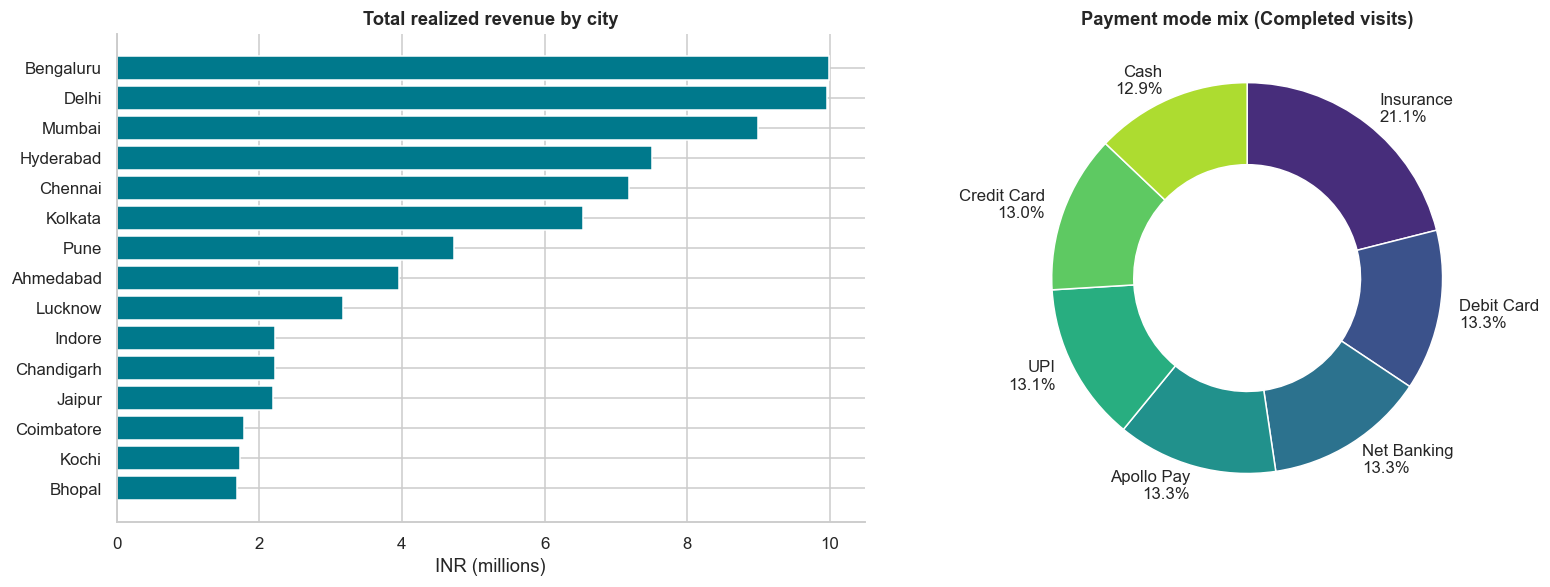

Top 3 cities (Bengaluru, Delhi, Mumbai) contribute 39.2% of total realized revenue
Insurance is the single largest payment mode at 21.1%; the remaining six modes split the rest fairly evenly (~13% each)


In [28]:
# 3.Which cities generate the most revenue, and what is the payment mode mix?
rev_city = completed.groupby('city').revenue_realized.sum().sort_values(ascending=False)
pay = completed.payment_mode.value_counts()

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
ax[0].barh(rev_city.index, rev_city.values / 1e6, color=TEAL); ax[0].invert_yaxis()
ax[0].set_title('Total realized revenue by city'); ax[0].set_xlabel('INR (millions)')
ax[1].pie(pay, labels=[f'{k}\n{v/pay.sum()*100:.1f}%' for k, v in pay.items()], startangle=90, counterclock=False,
          colors=sns.color_palette('viridis', len(pay)), wedgeprops=dict(width=0.42, edgecolor='white'))
ax[1].set_title('Payment mode mix (Completed visits)')
plt.tight_layout(); plt.show()
print(f'Top 3 cities ({", ".join(rev_city.index[:3])}) contribute {rev_city.iloc[:3].sum()/rev_city.sum()*100:.1f}% of total realized revenue')
print(f'Insurance is the single largest payment mode at {pay.iloc[0]/pay.sum()*100:.1f}%; the remaining six modes split the rest fairly evenly (~13% each)')

,avg_fee_charged,avg_out_of_pocket,avg_insurance_paid,appointments
insurance_coverage,,,,
No,"1,563.00","1,563.00",0.00,37523
Yes,"1,556.00",859.00,697.00,17752


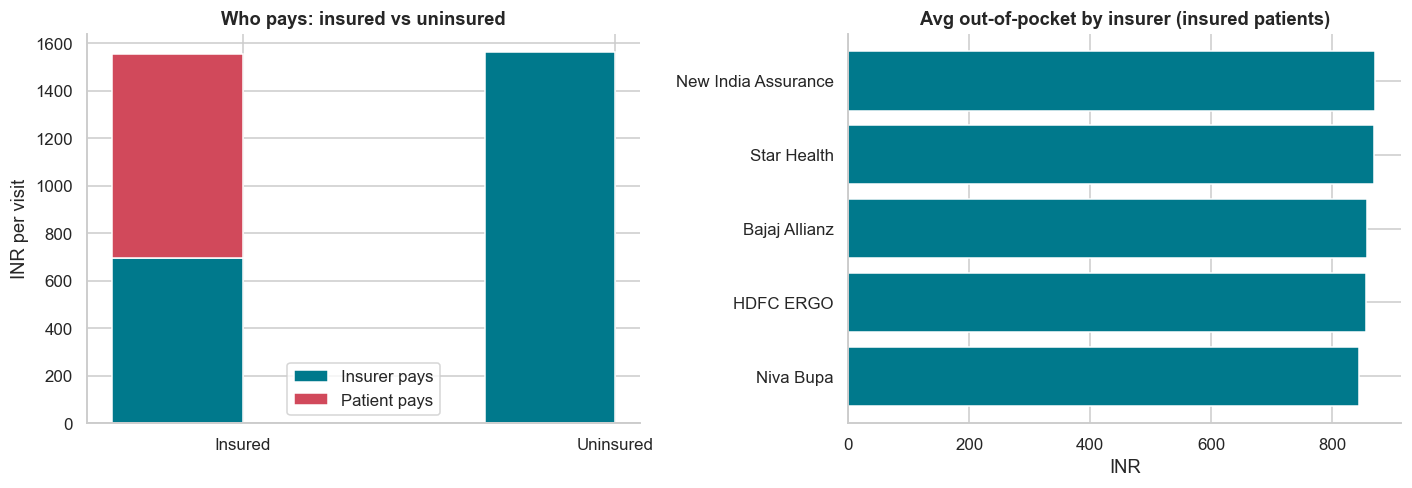

Insured patients pay INR 859 out of pocket on average vs INR 1,563 uninsured -> a 45% reduction; insurers cover INR 697 of the INR 1,556 average fee


In [29]:
# 4.How does insurance coverage affect what patients pay out of pocket?
ins = completed.groupby('insurance_coverage').agg(avg_fee_charged=('actual_fee_charged', 'mean'),
                                                    avg_out_of_pocket=('patient_out_of_pocket', 'mean'),
                                                    avg_insurance_paid=('insurance_covered_amount', 'mean'),
                                                    appointments=('actual_fee_charged', 'count'))
display(ins.round(0))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
x = np.arange(2); w = 0.35
ins_y = completed[completed.insurance_coverage == 'Yes']
ax[0].bar(x - w/2, [ins.loc['Yes', 'avg_insurance_paid'], ins.loc['No', 'avg_out_of_pocket']], w, label='Insurer pays', color=TEAL)
ax[0].bar(x - w/2, [ins.loc['Yes', 'avg_out_of_pocket'], 0], w, bottom=[ins.loc['Yes', 'avg_insurance_paid'], 0], label='Patient pays', color=RED)
ax[0].set_xticks(x); ax[0].set_xticklabels(['Insured', 'Uninsured']); ax[0].set_ylabel('INR per visit'); ax[0].legend(); ax[0].set_title('Who pays: insured vs uninsured')

prov = ins_y.groupby('insurance_provider').patient_out_of_pocket.mean().sort_values()
ax[1].barh(prov.index, prov.values, color=TEAL); ax[1].set_title('Avg out-of-pocket by insurer (insured patients)'); ax[1].set_xlabel('INR')
plt.tight_layout(); plt.show()

reduction = (1 - ins.loc['Yes', 'avg_out_of_pocket'] / ins.loc['No', 'avg_out_of_pocket']) * 100
print(f"Insured patients pay INR {ins.loc['Yes','avg_out_of_pocket']:,.0f} out of pocket on average vs INR {ins.loc['No','avg_out_of_pocket']:,.0f} uninsured "
      f"-> a {reduction:.0f}% reduction; insurers cover INR {ins.loc['Yes','avg_insurance_paid']:,.0f} of the INR {ins.loc['Yes','avg_fee_charged']:,.0f} average fee")

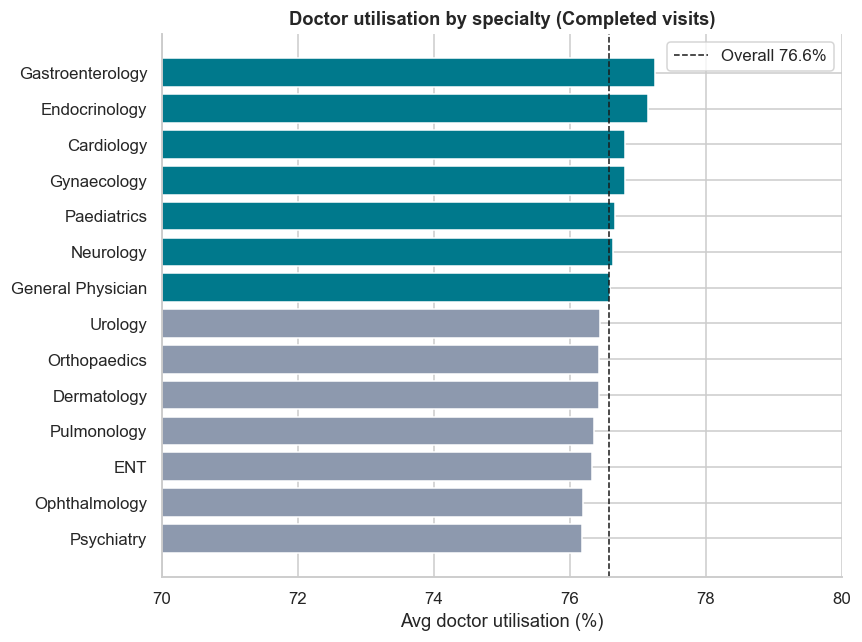

,avg_utilization,appointments
specialty,,
Gastroenterology,77.30,1972
Endocrinology,77.10,1504
Cardiology,76.80,3507
Gynaecology,76.80,3134
Paediatrics,76.70,4900
Neurology,76.60,3899
General Physician,76.60,14981
Urology,76.40,1729
Orthopaedics,76.40,4189


Range: 1.1 pp between Gastroenterology (highest) and Psychiatry (lowest)


In [30]:
#  Doctor utilisation & service quality
# 1.Which specialties have the highest and lowest doctor utilisation?
util = completed.groupby('specialty').doctor_utilization_pct.agg(avg_utilization='mean', appointments='count').sort_values('avg_utilization', ascending=False)
plt.figure(figsize=(8, 6))
plt.barh(util.index, util.avg_utilization, color=np.where(util.avg_utilization > completed.doctor_utilization_pct.mean(), TEAL, GREY))
plt.axvline(completed.doctor_utilization_pct.mean(), color='k', ls='--', lw=1, label=f"Overall {completed.doctor_utilization_pct.mean():.1f}%")
plt.gca().invert_yaxis(); plt.xlabel('Avg doctor utilisation (%)'); plt.title('Doctor utilisation by specialty (Completed visits)'); plt.legend()
plt.xlim(70, 80)
plt.tight_layout(); plt.show()
display(util.round(1))
print(f'Range: {util.avg_utilization.max()-util.avg_utilization.min():.1f} pp between {util.index[0]} (highest) and {util.index[-1]} (lowest)')

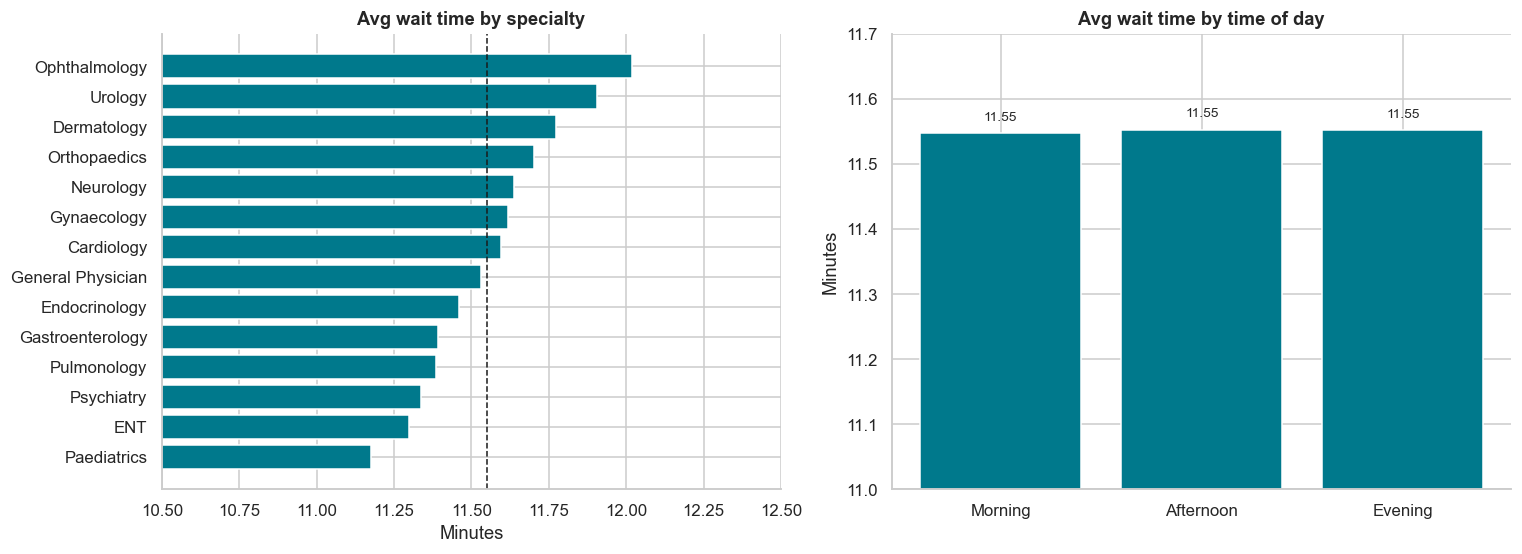

Overall avg wait: 11.55 min. Specialty range: 12.02 (Ophthalmology) to 11.18 min (Paediatrics)
Time-of-day range: 0.006 min -- essentially no difference


In [31]:
# 2.How long are patients waiting, and does it vary by specialty or time of day?
wait_spec = completed.groupby('specialty').wait_time_minutes.mean().sort_values(ascending=False)
wait_tod = completed.groupby('time_of_day').wait_time_minutes.mean().reindex(['Morning', 'Afternoon', 'Evening'])

fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))
ax[0].barh(wait_spec.index, wait_spec.values, color=TEAL); ax[0].invert_yaxis()
ax[0].axvline(completed.wait_time_minutes.mean(), color='k', ls='--', lw=1)
ax[0].set_title('Avg wait time by specialty'); ax[0].set_xlabel('Minutes'); ax[0].set_xlim(10.5, 12.5)
ax[1].bar(wait_tod.index, wait_tod.values, color=TEAL)
for x, v in enumerate(wait_tod.values): ax[1].text(x, v + .02, f'{v:.2f}', ha='center', fontsize=9)
ax[1].set_title('Avg wait time by time of day'); ax[1].set_ylabel('Minutes'); ax[1].set_ylim(11, 11.7)
plt.tight_layout(); plt.show()
print(f'Overall avg wait: {completed.wait_time_minutes.mean():.2f} min. Specialty range: {wait_spec.max():.2f} ({wait_spec.index[0]}) to {wait_spec.min():.2f} min ({wait_spec.index[-1]})')
print(f'Time-of-day range: {wait_tod.max()-wait_tod.min():.3f} min -- essentially no difference')

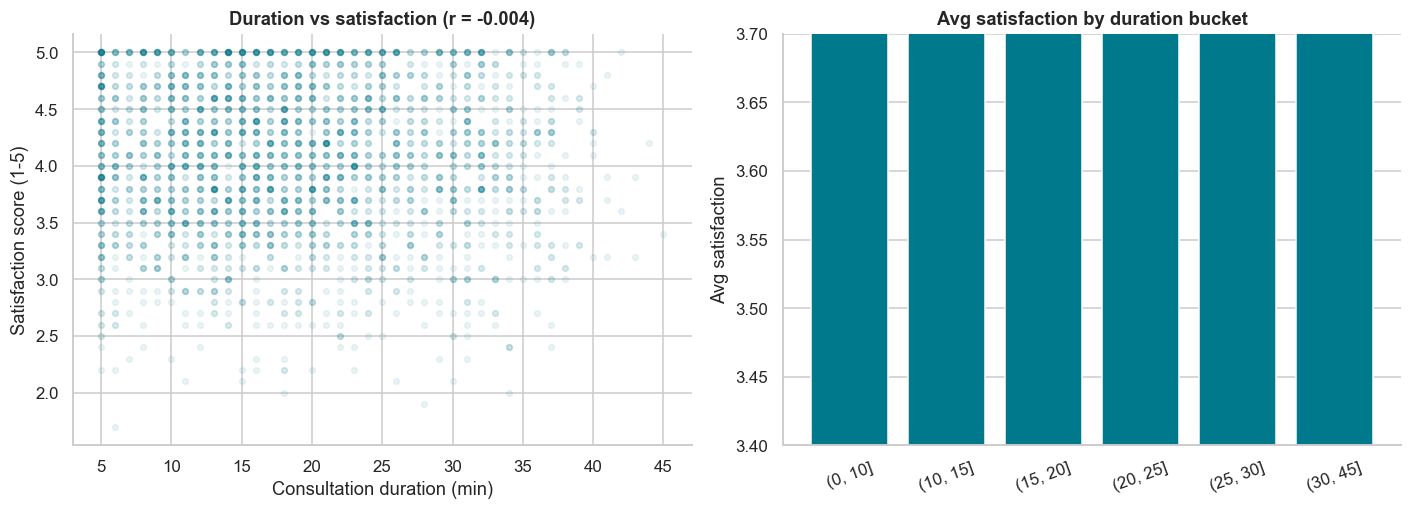

Pearson correlation: r = -0.004 (essentially zero)
p-value = 0.410 -> not statistically significant at alpha=0.05


In [32]:
# 3.Is there a relationship between consultation duration and patient satisfaction?
corr = completed[['consultation_duration_min', 'patient_satisfaction_score']].corr().iloc[0, 1]
sat_by_dur = completed.assign(dur_bucket=pd.cut(completed.consultation_duration_min, [0, 10, 15, 20, 25, 30, 45])).groupby('dur_bucket', observed=True).patient_satisfaction_score.agg(['mean', 'count'])

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
sample = completed.sample(min(3000, len(completed)), random_state=0)
ax[0].scatter(sample.consultation_duration_min, sample.patient_satisfaction_score, alpha=.08, s=14, color=TEAL)
ax[0].set_xlabel('Consultation duration (min)'); ax[0].set_ylabel('Satisfaction score (1-5)'); ax[0].set_title(f'Duration vs satisfaction (r = {corr:.3f})')
ax[1].bar(sat_by_dur.index.astype(str), sat_by_dur['mean'], color=TEAL)
ax[1].set_ylim(3.4, 3.7); ax[1].set_ylabel('Avg satisfaction'); ax[1].set_title('Avg satisfaction by duration bucket'); ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()
print(f'Pearson correlation: r = {corr:.3f} (essentially zero)')
r2, p2 = stats.pearsonr(completed.consultation_duration_min, completed.patient_satisfaction_score)
print(f'p-value = {p2:.3f} -> {"not" if p2 > 0.05 else ""} statistically significant at alpha=0.05')

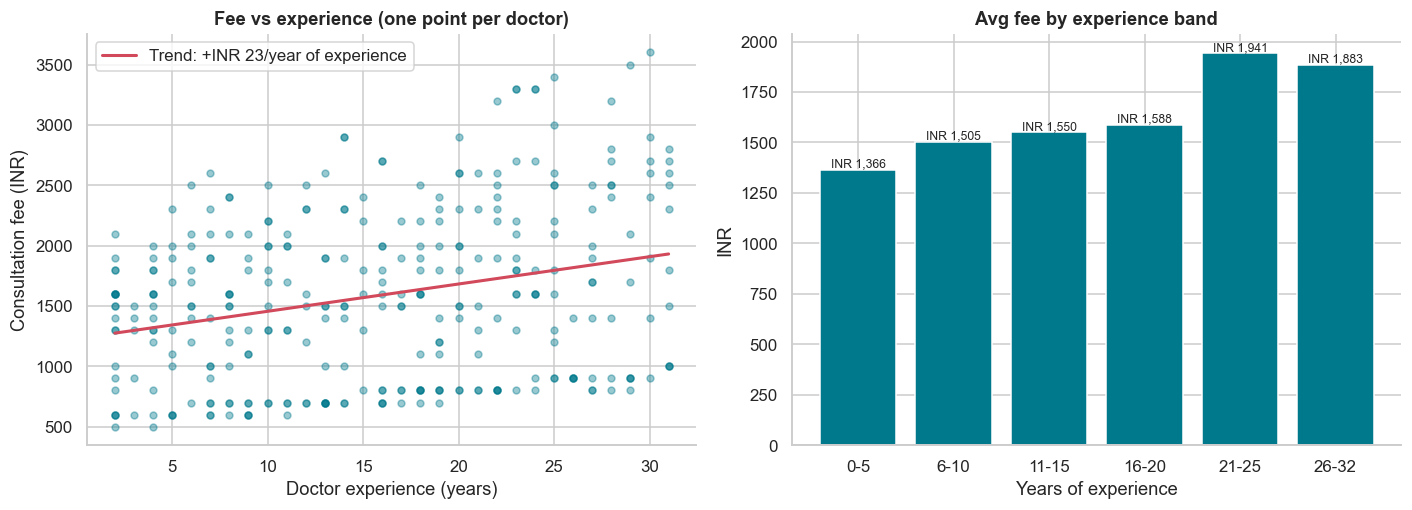

Doctor-level correlation (experience vs fee): r = 0.278
Fee roughly rises from INR 1,366 (0-5 yrs) to INR 1,941 (21-25 yrs), then flattens for the most senior band


In [33]:
# 4. How does doctor experience relate to the fee charged? (joined with the doctors dimension)
merged = fact.merge(doctors[['doctor_id', 'experience_years', 'rating']], on='doctor_id', suffixes=('', '_doc'))
exp_corr = merged[['experience_years', 'consultation_fee']].corr().iloc[0, 1]
exp_bucket = pd.cut(merged.experience_years, [0, 5, 10, 15, 20, 25, 32], labels=['0-5', '6-10', '11-15', '16-20', '21-25', '26-32'])
by_exp = merged.assign(exp_bucket=exp_bucket).groupby('exp_bucket', observed=True).consultation_fee.agg(['mean', 'count'])

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
doc_level = doctors.copy()
ax[0].scatter(doc_level.experience_years, doc_level.consultation_fee, alpha=.4, s=20, color=TEAL)
z = np.polyfit(doc_level.experience_years, doc_level.consultation_fee, 1)
xs = np.linspace(doc_level.experience_years.min(), doc_level.experience_years.max(), 50)
ax[0].plot(xs, np.polyval(z, xs), color=RED, lw=2, label=f'Trend: +INR {z[0]:.0f}/year of experience')
ax[0].set_xlabel('Doctor experience (years)'); ax[0].set_ylabel('Consultation fee (INR)'); ax[0].set_title('Fee vs experience (one point per doctor)'); ax[0].legend()
ax[1].bar(by_exp.index.astype(str), by_exp['mean'], color=TEAL)
for x, (v, n) in enumerate(zip(by_exp['mean'], by_exp['count'])): ax[1].text(x, v + 15, f'INR {v:,.0f}', ha='center', fontsize=8)
ax[1].set_title('Avg fee by experience band'); ax[1].set_ylabel('INR'); ax[1].set_xlabel('Years of experience')
plt.tight_layout(); plt.show()

doc_corr = doc_level[['experience_years', 'consultation_fee']].corr().iloc[0, 1]
print(f'Doctor-level correlation (experience vs fee): r = {doc_corr:.3f}')
print(f'Fee roughly rises from INR {by_exp["mean"].iloc[0]:,.0f} (0-5 yrs) to INR {by_exp["mean"].iloc[-2]:,.0f} (21-25 yrs), '
      f'then flattens for the most senior band')